# Train & đánh giá — YOLOv11
**Đồ án — Model 1: detector class-agnostic (1 lớp `product`)**

- Checkpoint riêng: `checkpoints/yolov11/`
- Epoch tối đa 100, early stopping qua `patience`
- Đánh giá cuối trên **tập test (19.200 ảnh)** bằng best.pt, chấm bằng COCOeval để đồng bộ thước đo với 2 model kia
- Ghi kết quả vào `comparison_results.json` theo schema chung

## Mount Drive & giải nén gold dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile
DRIVE_ZIP_PATH = '/content/drive/MyDrive/UIT/graduate_project/rpc_dataset/gold_dataset_detector_3models.zip'
EXTRACT_DIR = '/content/gold_dataset'
CHECKPOINT_DIR = '/content/drive/MyDrive/UIT/graduate_project/checkpoints/yolov11'
RESULTS_JSON = '/content/drive/MyDrive/UIT/graduate_project/checkpoints/comparison_results.json'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print("Đang giải nén gold dataset...")
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print("Xong.")
else:
    print("Đã tồn tại, bỏ qua.")


Mounted at /content/drive
Đang giải nén gold dataset...
Xong.


## data.yaml

Gold dataset `data.yaml` với 3 tập train/val/test

In [2]:
data_yaml = '''path: /content/gold_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names: ['product']
'''
with open('/content/gold_dataset/data.yaml', 'w') as f:
    f.write(data_yaml)
print(data_yaml)


path: /content/gold_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names: ['product']



## Train YOLOv11

`patience=15`: dừng nếu 15 epoch liên tiếp không cải thiện. đặt 100 epoch là còn số ước chừng, nếu 100 epoch đã qua mà learning curve vẫn tăng mạnh thì tiếp tục nâng lên, ngược lại nếu từ điểm đã đạt giá trị tối đa chạy thêm 15 epoch vẫn không đột phá giá trị tối đa mới thì dừng, để early stopping tự tìm điểm dừng.

In [3]:
!pip install -q ultralytics
from ultralytics import YOLO
import torch, time

model = YOLO('yolo11s.pt')
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t0 = time.time()
results = model.train(
    data='/content/gold_dataset/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    patience=15,
    project=CHECKPOINT_DIR,
    name='yolov11_product',
    exist_ok=True,
)
total_train_time = time.time() - t0
peak_mem = torch.cuda.max_memory_allocated()/1e9 if torch.cuda.is_available() else None
print(f"Tổng thời gian train: {total_train_time/60:.1f} phút")
if peak_mem: print(f"GPU peak: {peak_mem:.2f} GB")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gold_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0,

**Resume nếu Colab ngắt:** chạy cell dưới thay cho cell train ở trên:
```python
model = YOLO(f'{CHECKPOINT_DIR}/yolov11_product/weights/last.pt')
results = model.train(resume=True)
```

## Learning curve & epoch tốt nhất (từ results.csv)

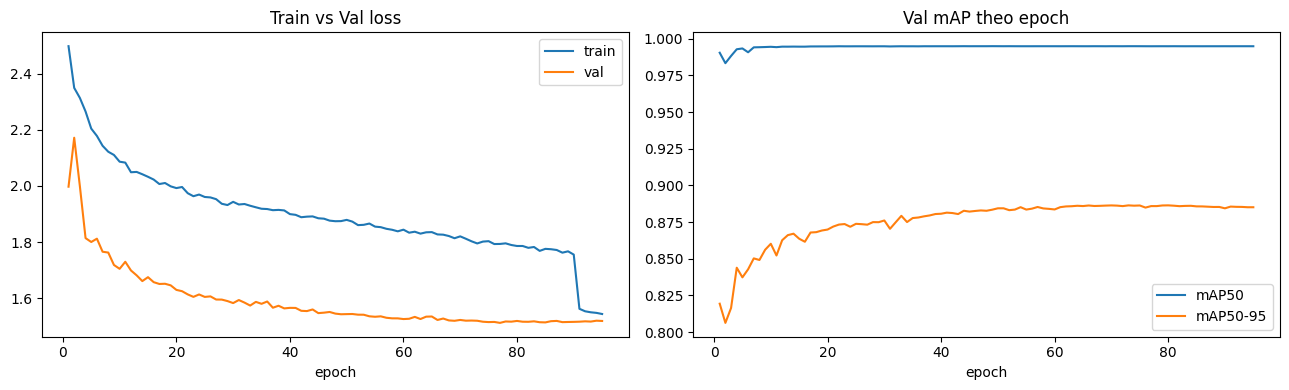

Epoch tốt nhất 80/95 | P 0.9986 R 0.9973 F1 0.9979


In [4]:
import pandas as pd, matplotlib.pyplot as plt
RESULTS_DIR = f'{CHECKPOINT_DIR}/yolov11_product'
hist = pd.read_csv(f'{RESULTS_DIR}/results.csv')
hist.columns = [c.strip() for c in hist.columns]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
tr = hist['train/box_loss'] + hist['train/cls_loss'] + hist['train/dfl_loss']
va = hist['val/box_loss'] + hist['val/cls_loss'] + hist['val/dfl_loss']
ax[0].plot(hist['epoch'], tr, label='train'); ax[0].plot(hist['epoch'], va, label='val')
ax[0].set_title('Train vs Val loss'); ax[0].legend(); ax[0].set_xlabel('epoch')
ax[1].plot(hist['epoch'], hist['metrics/mAP50(B)'], label='mAP50')
ax[1].plot(hist['epoch'], hist['metrics/mAP50-95(B)'], label='mAP50-95')
ax[1].set_title('Val mAP theo epoch'); ax[1].legend(); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/learning_curves_custom.png', dpi=120); plt.show()

bi = hist['metrics/mAP50-95(B)'].idxmax()
best_epoch = int(hist.loc[bi,'epoch']); total_epochs_run = int(hist['epoch'].max())
p_best = float(hist.loc[bi,'metrics/precision(B)']); r_best = float(hist.loc[bi,'metrics/recall(B)'])
f1_best = 2*p_best*r_best/(p_best+r_best+1e-9)
print(f"Epoch tốt nhất {best_epoch}/{total_epochs_run} | P {p_best:.4f} R {r_best:.4f} F1 {f1_best:.4f}")
if total_epochs_run >= 100:
    print("Đã chạy hết 100 epoch — kiểm tra mAP còn tăng không?")


## Hiển thị PR/F1 Curve & Confusion Matrix (ultralytics tự sinh)

--- confusion_matrix.png ---


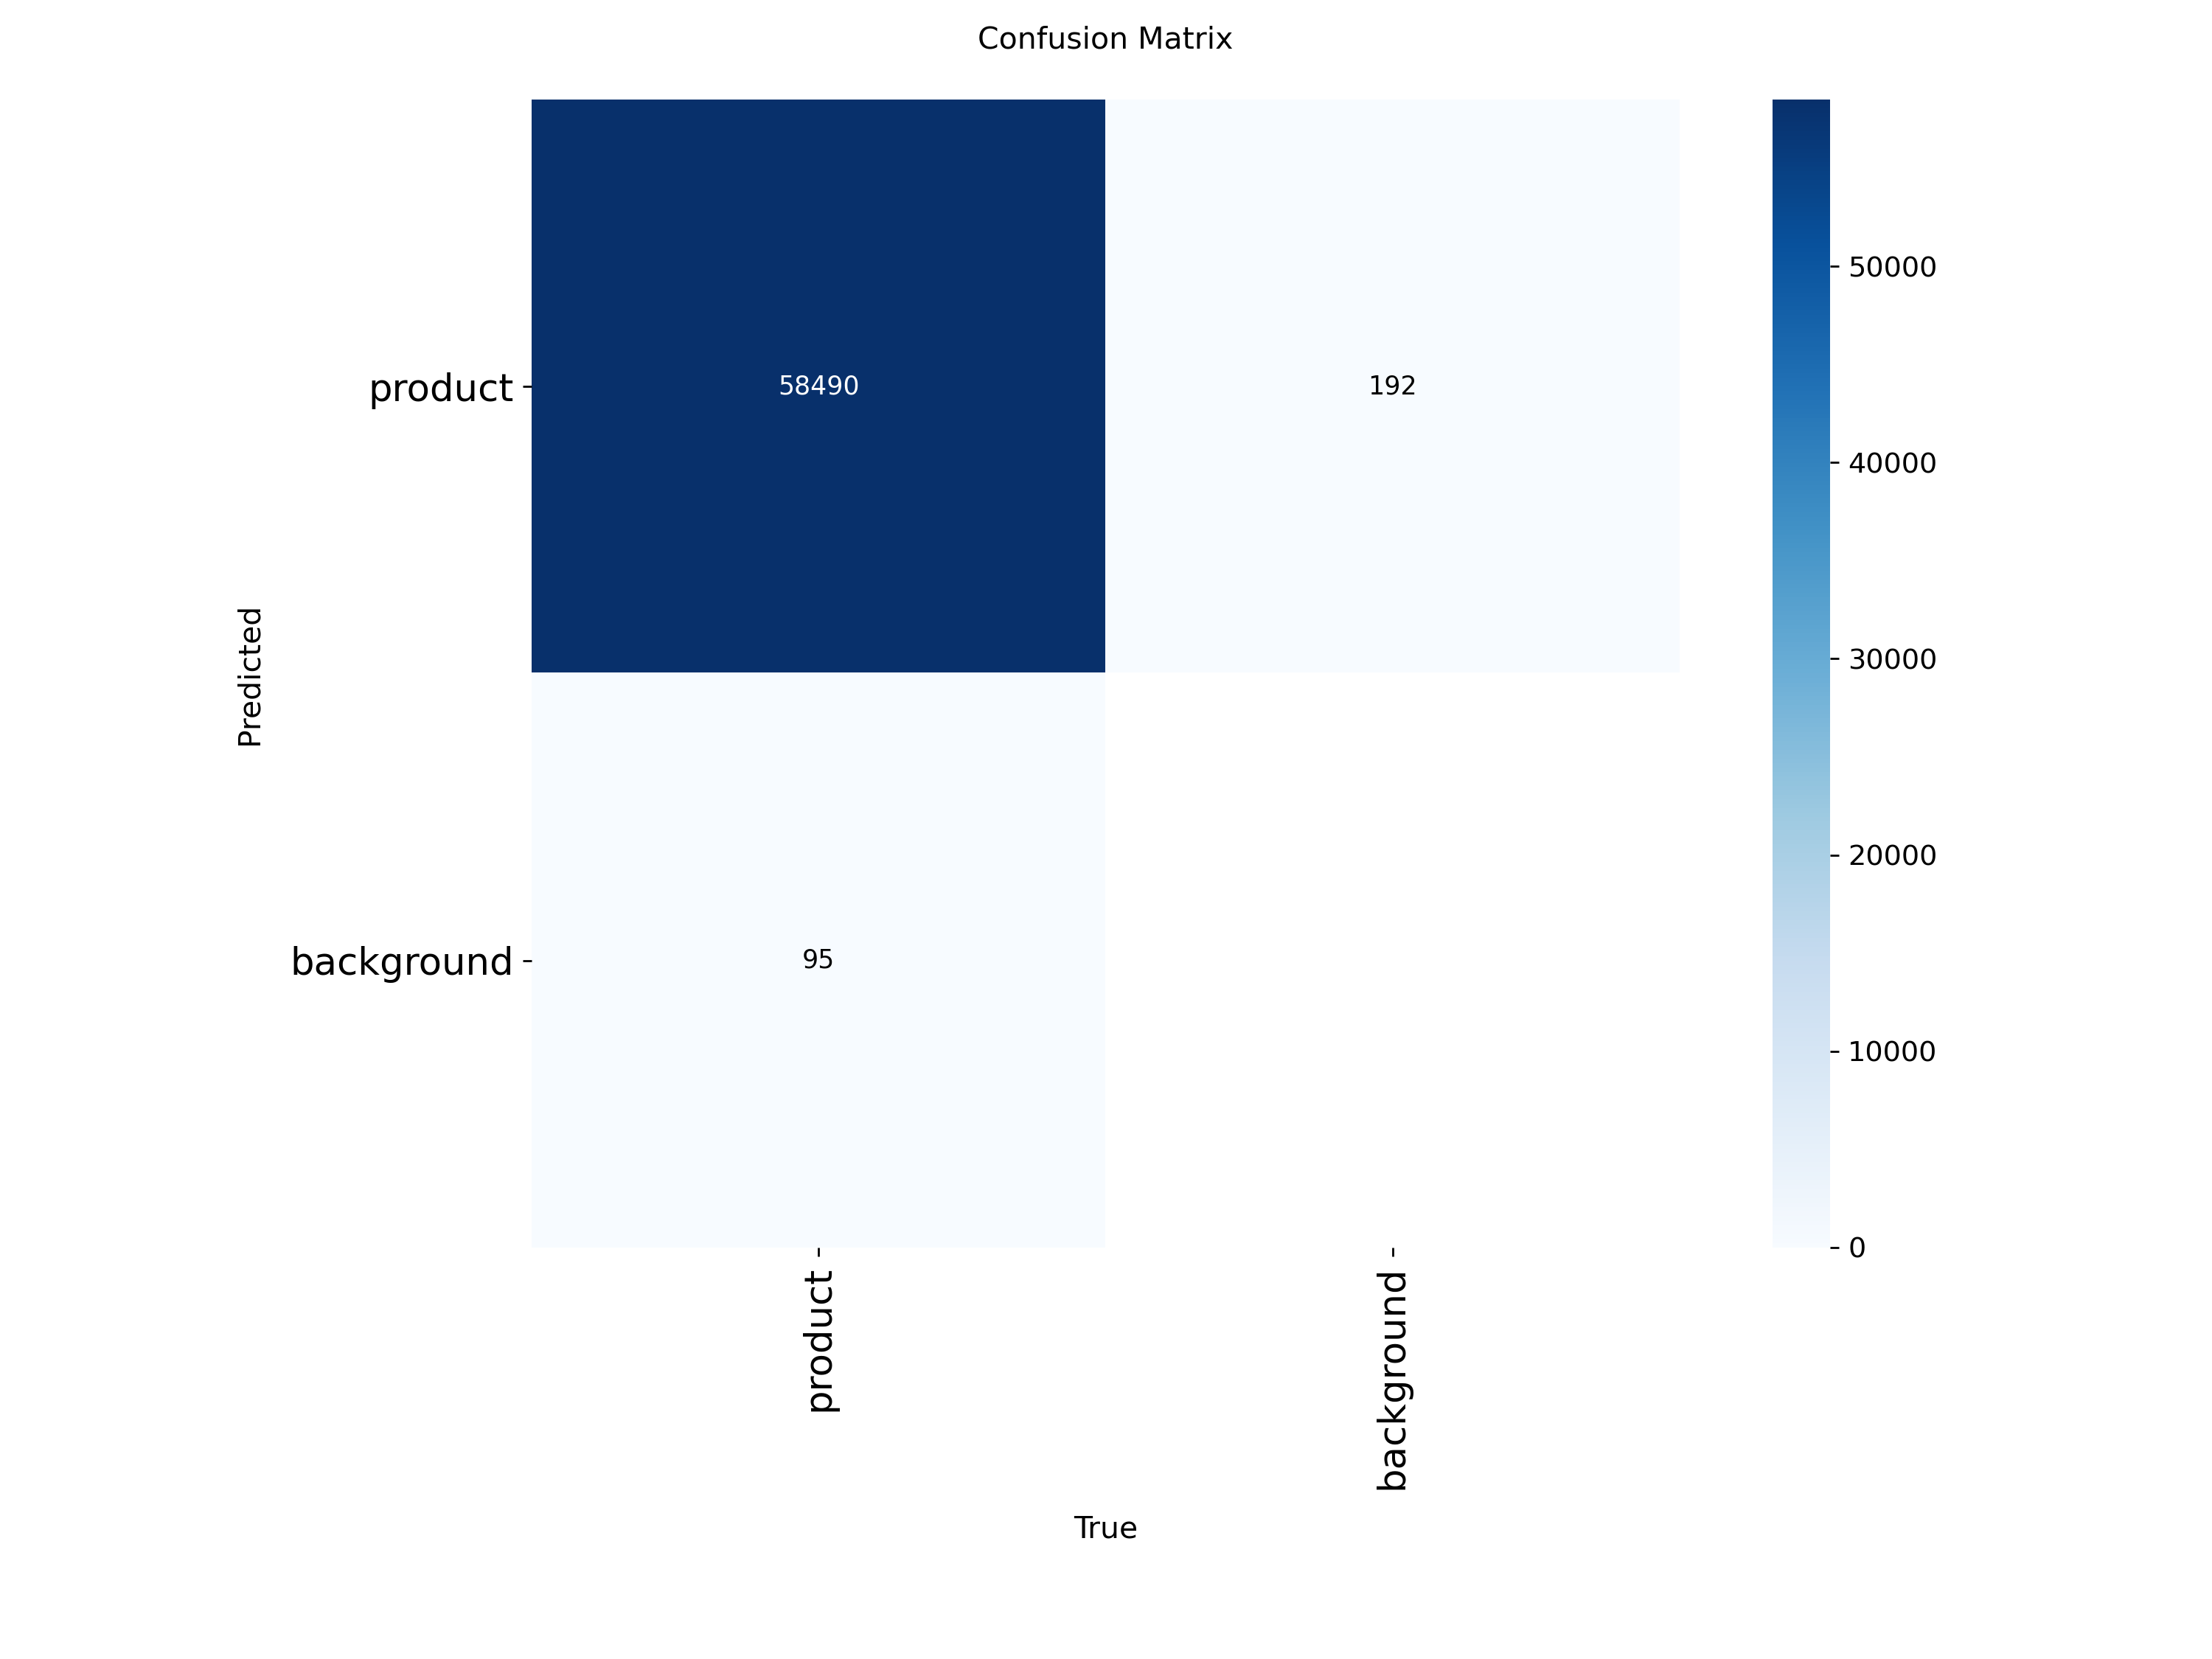

--- results.png ---


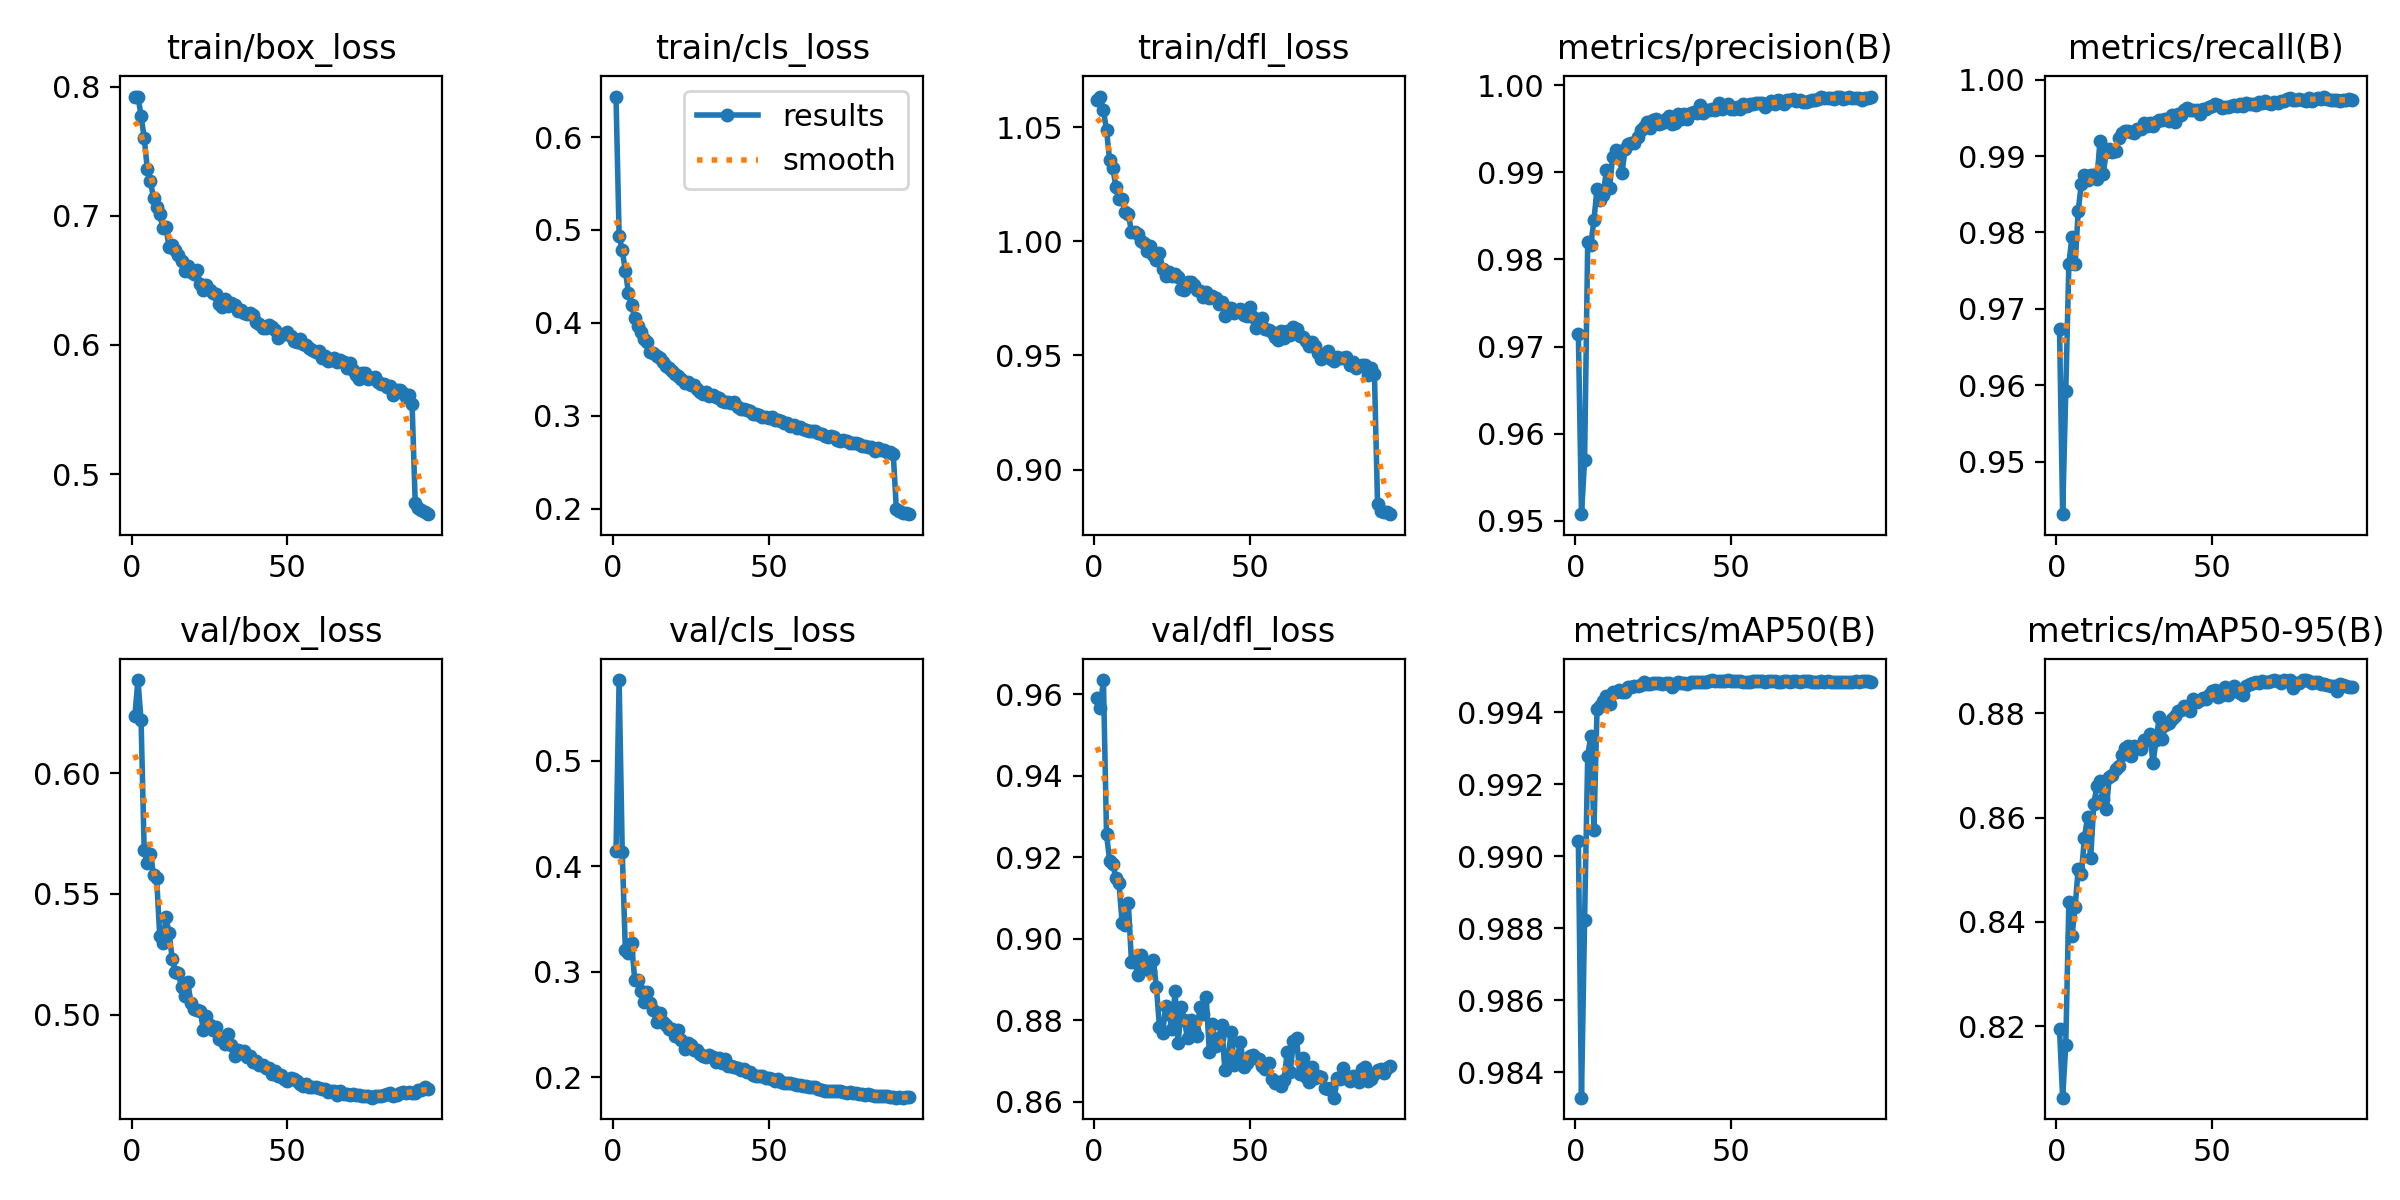

In [5]:
from IPython.display import Image as IPImage, display
for fname in ['PR_curve.png','F1_curve.png','confusion_matrix.png','results.png']:
    fp = f'{RESULTS_DIR}/{fname}'
    if os.path.exists(fp):
        print('---', fname, '---'); display(IPImage(filename=fp, width=560))


## Đánh giá CUỐI trên tập TEST (19.200 ảnh) bằng COCOeval

Dùng best.pt, xuất prediction ra COCO rồi chấm bằng pycocotools để có cùng thước đo (AP theo size, AR...) với Faster R-CNN / RetinaNet.

In [7]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json

best_pt = f'{RESULTS_DIR}/weights/best.pt'
model = YOLO(best_pt)

# split='test' -> ultralytics đánh giá trên images/test, save_json xuất predictions.json COCO
val_out = model.val(data='/content/gold_dataset/data.yaml', split='test',
                    save_json=True, project=CHECKPOINT_DIR, name='yolov11_test_eval', exist_ok=True)

PRED = f'{CHECKPOINT_DIR}/yolov11_test_eval/predictions.json'
GT = '/content/gold_dataset/coco_annotations/instances_test.json'
coco_gt = COCO(GT)
# Map tên file -> image_id trong ground-truth
fname_to_id = {img['file_name']: img['id'] for img in coco_gt.dataset['images']}

# Đọc predictions của ultralytics, image_id cần phải khớp GT
with open(PRED) as f:
    preds = json.load(f)

# ultralytics lưu image_id là tên file (không đuôi) hoặc số
id_to_fname = {img['id']: img['file_name'] for img in coco_gt.dataset['images']}
stem_to_id = {img['file_name'].rsplit('.',1)[0]: img['id'] for img in coco_gt.dataset['images']}

fixed = []
for p in preds:
    iid = p['image_id']
    if iid in id_to_fname: # đã đúng id
        fixed.append(p)
    elif str(iid) in stem_to_id: # id là tên file không đuôi
        p['image_id'] = stem_to_id[str(iid)]
        fixed.append(p)

print(f"Số prediction khớp được: {len(fixed)}/{len(preds)}")

PRED_FIXED = PRED.replace('.json', '_fixed.json')
with open(PRED_FIXED, 'w') as f:
    json.dump(fixed, f)

coco_dt = coco_gt.loadRes(PRED_FIXED)
ce = COCOeval(coco_gt, coco_dt, iouType='bbox')
ce.evaluate(); ce.accumulate(); ce.summarize()
s = ce.stats
map50_95=float(s[0]); map50=float(s[1]); map75=float(s[2])
ap_s=float(s[3]); ap_m=float(s[4]); ap_l=float(s[5])
ar100=float(s[8]); ar_s=float(s[9]); ar_m=float(s[10]); ar_l=float(s[11])
print(f"AP small {ap_s:.4f} | AR small {ar_s:.4f}")

inf_ms = float(val_out.speed['inference']); fps = 1000.0/inf_ms
print(f"FPS {fps:.2f} | {inf_ms:.2f} ms/anh")


Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2330.5±556.6 MB/s, size: 220.7 KB)
val: Scanning /content/gold_dataset/labels/test.cache... 19200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19200/19200 5.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1200/1200 3.9it/s 5:07
                   all      19200     235748      0.998      0.997      0.995      0.886
Speed: 0.8ms preprocess, 10.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Saving /content/drive/MyDrive/UIT/graduate_project/checkpoints/yolov11/yolov11_test_eval/predictions.json...
Results saved to /content/drive/MyDrive/UIT/graduate_project/checkpoints/yolov11/yolov11_test_eval
loading annotations into memory...
Done (t=0.72s)
creating index...
index created!
Số predictio

## Số tham số & lưu kết quả theo schema chung

In [8]:
n_params = sum(p.numel() for p in model.model.parameters())

# TP/FP/FN của YOLO lấy từ confusion matrix trên tập test (1 lớp)
# ultralytics: matrix[0,0]=TP, matrix[0,1]=FP, matrix[1,0]=FN (xấp xỉ cho bài 1 lớp)
try:
    cm = val_out.confusion_matrix.matrix
    TP = int(cm[0,0]); FP = int(cm[0,1]); FN = int(cm[1,0])
except Exception:
    TP = FP = FN = None

# precision/recall/f1 từ kết quả val trên test
try:
    p_test = float(val_out.box.mp); r_test = float(val_out.box.mr)
    f1_test = 2*p_test*r_test/(p_test+r_test+1e-9)
except Exception:
    p_test, r_test, f1_test = p_best, r_best, f1_best

def save_result(name, d, path=RESULTS_JSON):
    allr = json.load(open(path)) if os.path.exists(path) else {}
    allr[name] = d
    json.dump(allr, open(path,'w'), indent=2, ensure_ascii=False)
    print("Da luu:", name)

save_result('YOLOv11', {
    'mAP50': map50, 'mAP50_95': map50_95, 'mAP75': map75,
    'AP_small': ap_s, 'AP_medium': ap_m, 'AP_large': ap_l,
    'AR_max100': ar100, 'AR_small': ar_s, 'AR_medium': ar_m, 'AR_large': ar_l,
    'precision': p_test, 'recall': r_test, 'f1_score': f1_test,
    'TP': TP, 'FP': FP, 'FN': FN,
    'best_epoch': best_epoch, 'total_epochs_run': total_epochs_run,
    'fps': fps, 'inference_ms': inf_ms,
    'n_params': int(n_params), 'n_params_millions': round(n_params/1e6, 2),
    'total_train_time_min': round(total_train_time/60, 2),
    'peak_gpu_mem_gb': round(peak_mem, 2) if peak_mem else None,
    'eval_split': 'test (19200 anh)',
})


Da luu: YOLOv11
